#Session 3 
In this session I was building ML model that predicts  a client's choice on subscribing to a term deposit based on the Portugese Bank's marketing campaign. The choice was either yes or no, thereby making this tutorial about a binary classification model based.



# ACTIVITIES DONE
The process involved, setting up the buiilding environment, data loading, EDA, Data Preprocessing, Data Split, Model Selection and MOdel Evaluation

# 1. Setting up the environment

This stage involved importing necessary libraries need to build a binary classification.

In [2]:
#importing and mounting
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Data Loading
In this stage, pandas were used to read and store the data on a variable called data from the mouted drive.


In [3]:
#mapping and read the file using by first declaring filepath
file_path = '/content/drive/My Drive/bank-full2.csv'
data = pd.read_csv(file_path, delimiter=';')

# 3. Exploratory Data Analysis
This stage involved assessing the data to find key pattern, distribution and relationship of the features. Seaborn and matplotlib were used to visualize data.

In [4]:
#Displaying the first few rows of the dataset to see the structure and general info
data.head(), data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


(   age           job  marital  education default  balance housing loan  \
 0   58    management  married   tertiary      no     2143     yes   no   
 1   44    technician   single  secondary      no       29     yes   no   
 2   33  entrepreneur  married  secondary      no        2     yes  yes   
 3   47   blue-collar  married    unknown      no     1506     yes   no   
 4   33       unknown   single    unknown      no        1      no   no   
 
    contact  day month  duration  campaign  pdays  previous poutcome   y  
 0  unknown    5   may       261         1     -1         0  unknown  no  
 1  unknown    5   may       151         1     -1         0  unknown  no  
 2  unknown    5   may        76         1     -1         0  unknown  no  
 3  unknown    5   may        92         1     -1         0  unknown  no  
 4  unknown    5   may       198         1     -1         0  unknown  no  ,
 None)

In [5]:
#Checking for missing values
print(data.isnull().sum())


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


###Anayzing categorical and numerical variables

In [6]:
#first we separate the categorial and numerical variables
categorical_vars = data.select_dtypes(include=['object']).columns.tolist()
numerical_vars = data.select_dtypes(include=['number']).columns.tolist()

print(numerical_vars)

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [7]:
#then we summarize the categorical variable, looping over each categorical columns counting each unique var
categorical_summary = {col: data[col].value_counts() for col in categorical_vars}

print(categorical_summary)

{'job': job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64, 'marital': marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64, 'education': education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64, 'default': default
no     44396
yes      815
Name: count, dtype: int64, 'housing': housing
yes    25130
no     20081
Name: count, dtype: int64, 'loan': loan
no     37967
yes     7244
Name: count, dtype: int64, 'contact': contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64, 'month': month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477


Interpretation of the categorical coloumns, the data shows that there 10  categorical columns with each columns contains more than one unique var labels. Following is the break down of the these vars per column
* Job : Contains 12 unique variable labels namely; Self-employed, unemployed, Entrepreneur, Student, Technician, Management, admin, Blue-collar, Housemaid, Retired, Services, Unknown. With the most popular/ frequent job being blue-collar followed by management and technician. Meanwhile other categories such as  housemaid, student and unknown are less frequent. Indicating that the data is more biased towards blue-collar, management and technician jobs.
*Marial Status : Has 3 unique variable labels, married, single , and divorced. With Married being the most frequent with numbers over the two labels combined, thus indicating that the data is more distributed at married people.

* The data shows that more clients are rejecting subscribing to a term deposit thereby indicating that the target class is imbalanced.




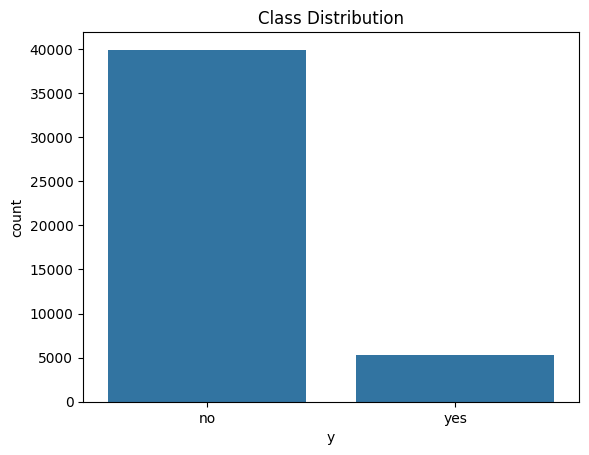

In [7]:
# visualizing the target class, to see the balance or imbalance of it

sns.countplot(data=data, x='y')
plt.title('Class Distribution')
plt.show()



This visual further indicates the imbalance. Calling for immediate balancing to reduce the model bias.

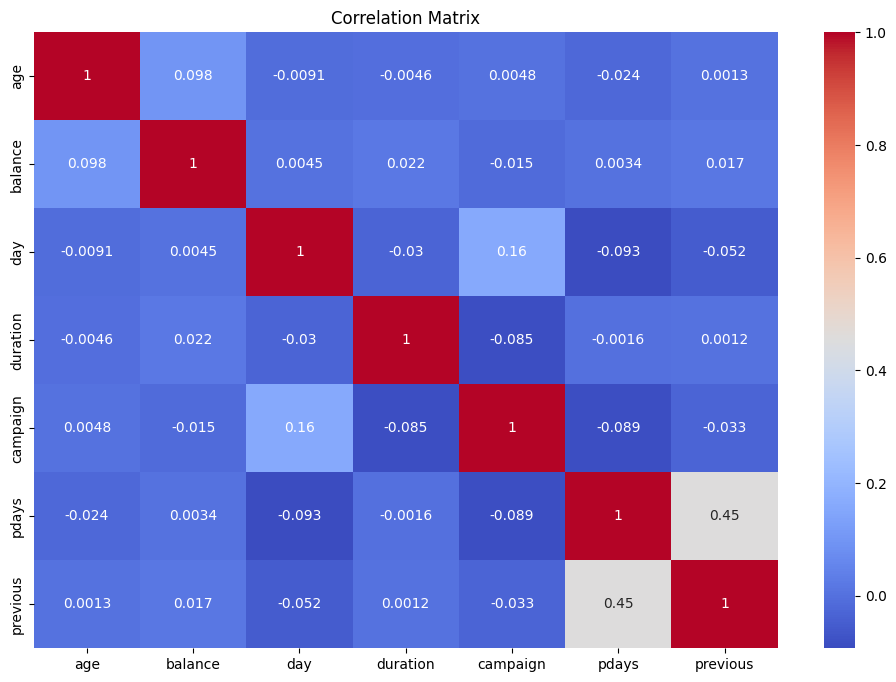

In [10]:
# checking the correlation of other features

plt.figure(figsize=(12, 8))
sns.heatmap(data[numerical_vars].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



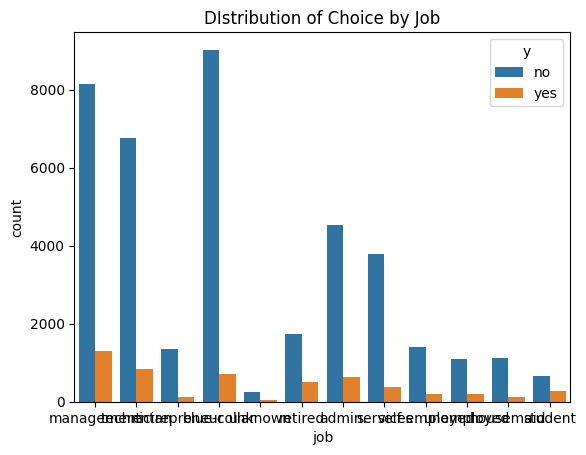

In [11]:
#checking the distribution on job vs choice
sns.countplot(data=data, x='job', hue='y')
plt.title('DIstribution of Choice by Job')
plt.show()

# 4. Data Preprocessing


In [8]:
#Handling class imbalance using undersampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#encoding the target as binary
data['y'] = data['y'].map({'yes': 1, 'no': 0})

#droping the taget from features
x = data.drop('y', axis=1)
y = data['y']

#converting categorical features to numerical
x = pd.get_dummies(x)


#applying smote
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(x, y)

#combine resampled features
data_resampled = pd.concat([X_resampled, y_resampled], axis=1)

# Display the new distribution of the target variable
print("\nNew distribution of 'choice' after applying SMOTE:")
print(data_resampled['y'].value_counts())

#applying random undersampling
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_rus, Y_rus = rus.fit_resample(x,y)

#combine
data_undersampled = pd.concat([X_rus, Y_rus], axis=1)
# Display the new distribution of the target variable
print("\nNew distribution of 'y' after applying Random Undersampling:")
print(data_undersampled['y'].value_counts())




New distribution of 'choice' after applying SMOTE:
y
0    39922
1    39922
Name: count, dtype: int64

New distribution of 'y' after applying Random Undersampling:
y
0    5289
1    5289
Name: count, dtype: int64


In [9]:
#spliting data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X_rus, Y_rus,
                                    test_size=0.2, random_state=42)

In [10]:
#scaling the numeric values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
#defining the model
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
#model compiling
model.compile(optimizer='adam', loss='binary_crossentropy', metrics = ['accuracy'])


In [13]:
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6512 - loss: 0.6150 - val_accuracy: 0.8376 - val_loss: 0.3960
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8336 - loss: 0.3879 - val_accuracy: 0.8547 - val_loss: 0.3697
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8522 - loss: 0.3623 - val_accuracy: 0.8571 - val_loss: 0.3660
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8559 - loss: 0.3453 - val_accuracy: 0.8565 - val_loss: 0.3578
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8654 - loss: 0.3259 - val_accuracy: 0.8594 - val_loss: 0.3513
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8609 - loss: 0.3295 - val_accuracy: 0.8600 - val_loss: 0.3510
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8675 - loss: 0.3167 - val_accuracy: 0.8588 - val_loss: 0.3431
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8696 - loss: 0.3056 - val_accuracy: 0.

In [14]:
# Ensure data types are correct
X_test = np.asarray(X_test).astype('float32')
y_test = np.asarray(y_test).astype('int32')

# Check for missing values
print(np.isnan(X_test).sum())
print(np.isnan(y_test).sum())

# Print shapes and data types
print(X_test.shape, X_test.dtype)
print(y_test.shape, y_test.dtype)

# Print a few samples
print(X_test[:5])
print(y_test[:5])

0
0
(2116, 51) float32
(2116,) int32
[[ 3.900e+01  5.170e+02  1.400e+01  1.328e+03  1.000e+00 -1.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  1.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  1.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   1.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00  1.000e+00
   0.000e+00  1.000e+00  0.000e+00  0.000e+00  1.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  1.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  1.000e+00]
 [ 3.000e+01  3.929e+03  2.000e+01  5.930e+02  1.000e+00 -1.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00  1.000e+00
   0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00  1.000e+00
   1.000e+00  0.000e+00  1.000e+00  0.000e+

In [15]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4871 - loss: 409.5125
Test Accuracy: 0.4839319586753845


The model is way overfiiting, meaning that it performs better in seen data than unseen

In [18]:
# Import necessary libraries
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist  # Example dataset

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess data: Flatten and normalize
X_train = X_train.reshape((X_train.shape[0], -1)) / 255.0
X_test = X_test.reshape((X_test.shape[0], -1)) / 255.0

# Set up K-Fold Cross-Validation
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Function to create and compile the model
def create_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')  # Output layer for classification
    ])
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# List to store accuracy for each fold
accuracy_per_fold = []

# K-Fold Cross-Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f'Fold {fold + 1}')

    # Split the data into training and validation sets for this fold
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Create a new instance of the model for each fold
    model = create_model()

    # Train the model on the training fold
    model.fit(X_train_fold, y_train_fold, epochs=5, batch_size=32, verbose=0)

    # Evaluate the model on the validation fold
    val_predictions = np.argmax(model.predict(X_val_fold), axis=1)
    accuracy = accuracy_score(y_val_fold, val_predictions)

    # Store the accuracy for this fold
    accuracy_per_fold.append(accuracy)
    print(f'Accuracy for fold {fold + 1}: {accuracy * 100:.2f}%')

# Calculate the average accuracy across all folds
average_accuracy = np.mean(accuracy_per_fold)
print(f'\nAverage Accuracy Across {k} Folds: {average_accuracy * 100:.2f}%')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fold 1
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy for fold 1: 97.20%
Fold 2


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy for fold 2: 97.52%
Fold 3


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy for fold 3: 97.30%
Fold 4


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy for fold 4: 97.19%
Fold 5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy for fold 5: 97.39%

Average Accuracy Across 5 Folds: 97.32%


In [19]:
# Train the final model on the entire training dataset
final_model = create_model()
final_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Make predictions on the test set
test_predictions = np.argmax(final_model.predict(X_test), axis=1)

# Evaluate the model on the test set
test_accuracy = accuracy_score(y_test, test_predictions)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy: 97.91%


The model now performs better after using Kfold for cross validation, meaning it generalizes almost similar to the seen data.

Key points derived
- The model performs better in both seen and unseen data when cross-validation is used